# 🫀 Cardiovascular Disease Analysis — Exploratory Data Analysis

---

### 📌 Objective
Perform a complete Exploratory Data Analysis on a cardiovascular disease dataset of 70,000 patients to uncover patterns and risk factors associated with heart disease — including age, BMI, blood pressure, cholesterol and smoking status.

### 📂 Dataset
- **File:** cardio_train.csv
- **Rows:** 70,000 patients
- **Columns:** 13
- **Separator:** Semicolon (;)
- **Target Column:** `cardio` — 0 = No Disease, 1 = Has Disease
- **Age Range:** ~29 to ~65 years

### 🛠️ Tools Used
- **NumPy** — Numerical operations and BMI calculation
- **Pandas** — Data loading, cleaning, filtering and transformation
- **Matplotlib** — Core visualizations
- **Seaborn** — Statistical visualizations

### 📊 Analyses Performed
1. Cardiovascular Disease Distribution
2. Age Distribution of Patients
3. Age vs Cardiovascular Disease by Smoking Status
4. BMI Distribution with WHO Category Boundaries
5. Cardiovascular Disease Rate by Cholesterol Level
6. Height vs Weight by Disease Status
7. Average Blood Pressure Trend by Age
8. Final Dashboard

---

## 📦 Importing Libraries

In [1]:
# Importing all required libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Loading the Dataset

In [2]:
# Loading cardiovascular dataset — sep=';' because file uses semicolon as separator not comma
# df2 stores original, df is working copy — ensures raw data is never modified
df2 = pd.read_csv('cardio_train.csv', sep=';')
df = df2.copy()

## 🧹 Data Cleaning

Steps performed:
- Drop `id` column — unique identifier, not useful for analysis
- Convert `age` from days to years — original values stored in days
- Filter unrealistic blood pressure values — remove medically impossible readings
- Calculate BMI from height and weight
- Filter unrealistic BMI values

In [3]:
# Dropping id column — unique patient identifier, not needed for any analysis
df.drop(columns='id', inplace=True)

In [4]:
# Age is stored in days in the original dataset — converting to years by dividing by 365
# astype(int) removes decimal places — age is always expressed as a whole number
age = df['age'] / 365
df['age'] = age.astype(int)

In [5]:
# Filtering out medically impossible blood pressure readings
# Realistic systolic (ap_hi) range: 60–180 | Realistic diastolic (ap_lo) range: 40–120
# & operator combines both conditions — row must satisfy all criteria to be kept
df = df.loc[((df['ap_hi'] >= 60) & (df['ap_hi'] <= 180)) & ((df['ap_lo'] >= 40) & (df['ap_lo'] <= 120))]

In [6]:
# Calculating BMI — Body Mass Index formula: weight(kg) / height(m)²
# Height divided by 100 to convert cm to meters, then squared using np.square()
df['bmi'] = df['weight'] / np.square(df['height'] / 100)

In [7]:
# Removing unrealistic BMI values — keeping only medically possible range of 10 to 60
df = df.loc[((df['bmi'] >= 10) & (df['bmi'] <= 60))]

---
## 📊 Analysis 1 — Cardiovascular Disease Distribution

**Question:** What percentage of patients in this dataset have cardiovascular disease?

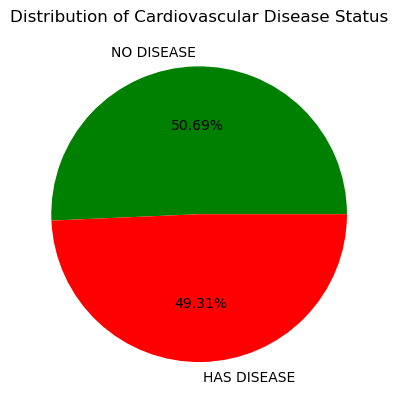

In [8]:
# Counting patients with and without cardiovascular disease
cardio = df['cardio'].value_counts()

# Pie chart — perfect for showing percentage split between two categories
# Green = No Disease, Red = Has Disease — intuitive medical color coding
plt.pie(cardio.values, labels=['NO DISEASE', 'HAS DISEASE'], autopct='%1.2f%%', colors=['green', 'red'])
plt.title('Distribution of Cardiovascular Disease Status')
plt.show()

## 📊 Analysis 2 — Age Distribution of Patients

**Question:** What age group is most common among patients in this dataset?

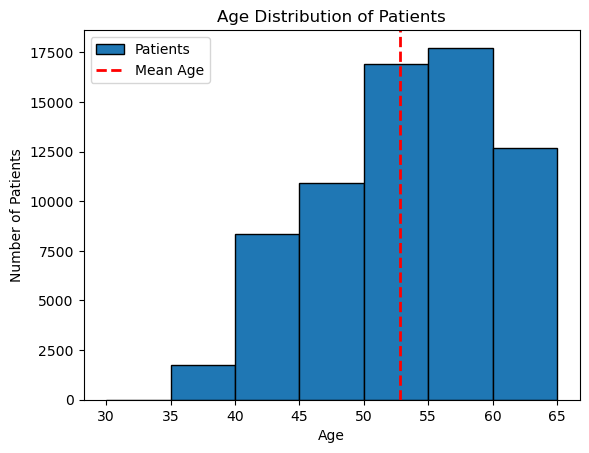

In [9]:
# Custom 5-year age group bins — medically meaningful intervals
bins = [30, 35, 40, 45, 50, 55, 60, 65]

# Histogram showing patient count in each age group
plt.hist(df['age'], bins=bins, edgecolor='black', label='Patients')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

# Red dashed vertical line marking the mean age across all patients
plt.axvline(x=df['age'].mean(), color='red', linestyle='--', linewidth=2, label='Mean Age')
plt.legend()
plt.show()

## 📊 Analysis 3 — Age vs Cardiovascular Disease by Smoking Status

**Question:** Are older patients more likely to have cardiovascular disease — and does smoking make it worse?

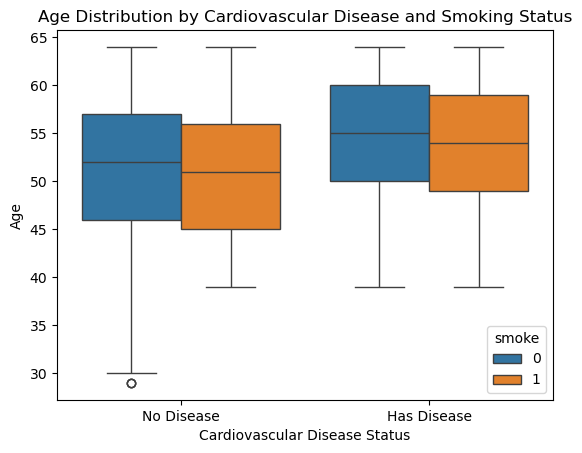

In [10]:
# Box plot comparing age distribution across disease and no-disease patient groups
# hue='smoke' adds smoking as a 3rd dimension — revealing 3 insights in one chart
sns.boxplot(x=df['cardio'], y=df['age'], hue=df['smoke'])
plt.title('Age Distribution by Cardiovascular Disease and Smoking Status')
plt.xlabel('Cardiovascular Disease Status')
plt.ylabel('Age')

# Replacing encoded 0/1 values with readable meaningful labels
plt.xticks([0, 1], ['No Disease', 'Has Disease'])
plt.show()

## 📊 Analysis 4 — BMI Distribution with WHO Category Boundaries

**Question:** What is the most common BMI range — and how many patients fall in each WHO medical category?

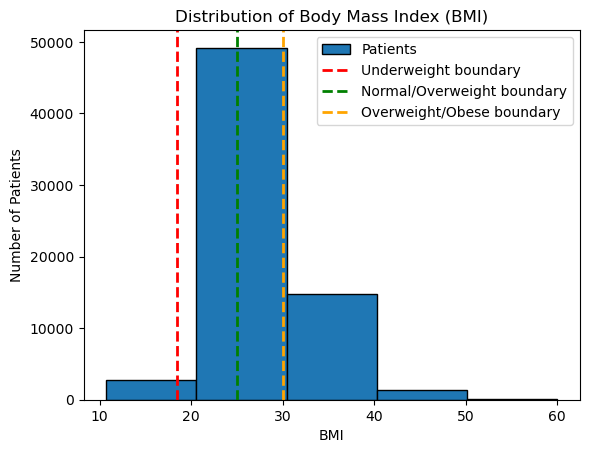

In [11]:
# Histogram showing BMI distribution across all patients
plt.hist(df['bmi'], bins=5, edgecolor='black', label='Patients')

# Three vertical reference lines marking standard WHO BMI category boundaries
# 18.5 = Underweight / Normal boundary
# 25   = Normal / Overweight boundary
# 30   = Overweight / Obese boundary
plt.axvline(x=18.5, color='red', linestyle='--', linewidth=2, label='Underweight boundary')
plt.axvline(x=25, color='green', linestyle='--', linewidth=2, label='Normal/Overweight boundary')
plt.axvline(x=30, color='orange', linestyle='--', linewidth=2, label='Overweight/Obese boundary')
plt.title('Distribution of Body Mass Index (BMI)')
plt.xlabel('BMI')
plt.ylabel('Number of Patients')
plt.legend()
plt.show()

## 📊 Analysis 5 — Cardiovascular Disease Rate by Cholesterol Level

**Question:** Does higher cholesterol increase the risk of cardiovascular disease?

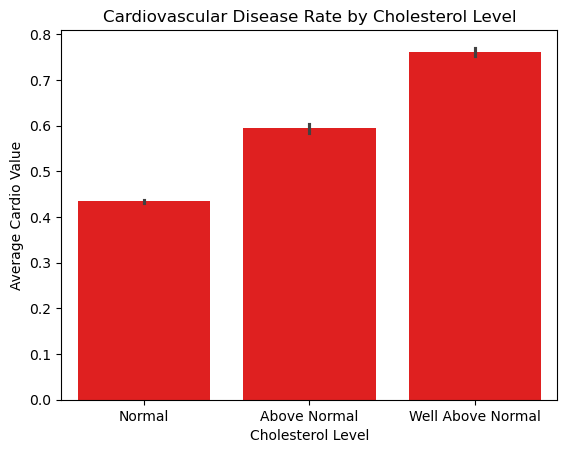

In [12]:
# Seaborn barplot automatically calculates mean of cardio per cholesterol group
# Since cardio is 0/1, mean directly represents disease probability for that group
# Clear upward trend confirms — higher cholesterol = higher cardiovascular disease risk
sns.barplot(x=df['cholesterol'], y=df['cardio'], color='red')
plt.title('Cardiovascular Disease Rate by Cholesterol Level')
plt.xlabel('Cholesterol Level')
plt.ylabel('Average Cardio Value')

# Replacing encoded 0/1/2 values with meaningful cholesterol category labels
plt.xticks([0, 1, 2], ['Normal', 'Above Normal', 'Well Above Normal'])
plt.show()

## 📊 Analysis 6 — Height vs Weight by Cardiovascular Disease Status

**Question:** Is there a visible pattern between height and weight across patients with and without cardiovascular disease?

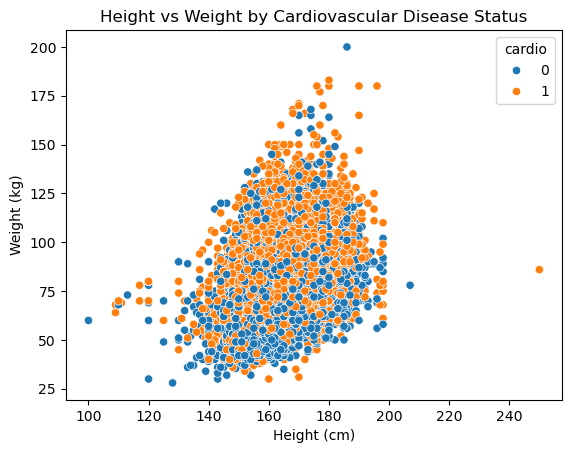

In [13]:
# Scatter plot with hue='cardio' colors each point by disease status automatically
# Seaborn chosen over Matplotlib — handles coloring and legend in one line
sns.scatterplot(df, x='height', y='weight', hue='cardio')
plt.title('Height vs Weight by Cardiovascular Disease Status')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

## 📊 Analysis 7 — Average Blood Pressure Trend by Age

**Question:** Does systolic blood pressure increase as patients get older?

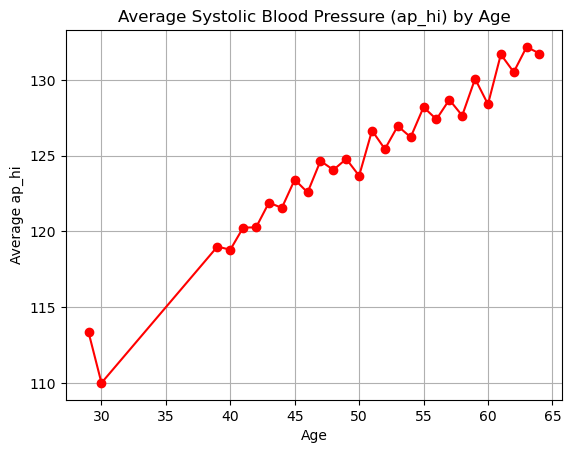

In [14]:
# Grouping by age and computing mean systolic blood pressure per age group
# Reveals how average BP changes across different patient age groups
data = df.groupby('age')['ap_hi'].mean()

# Line plot with markers — each point represents mean BP for that specific age
plt.plot(data.index, data.values, marker='o', color='red')
plt.title('Average Systolic Blood Pressure (ap_hi) by Age')
plt.xlabel('Age')
plt.ylabel('Average ap_hi')
plt.grid()
plt.show()

---
## 📊 Final Dashboard — Cardiovascular Analysis Summary

Combining the 6 most meaningful analyses into one complete dashboard.

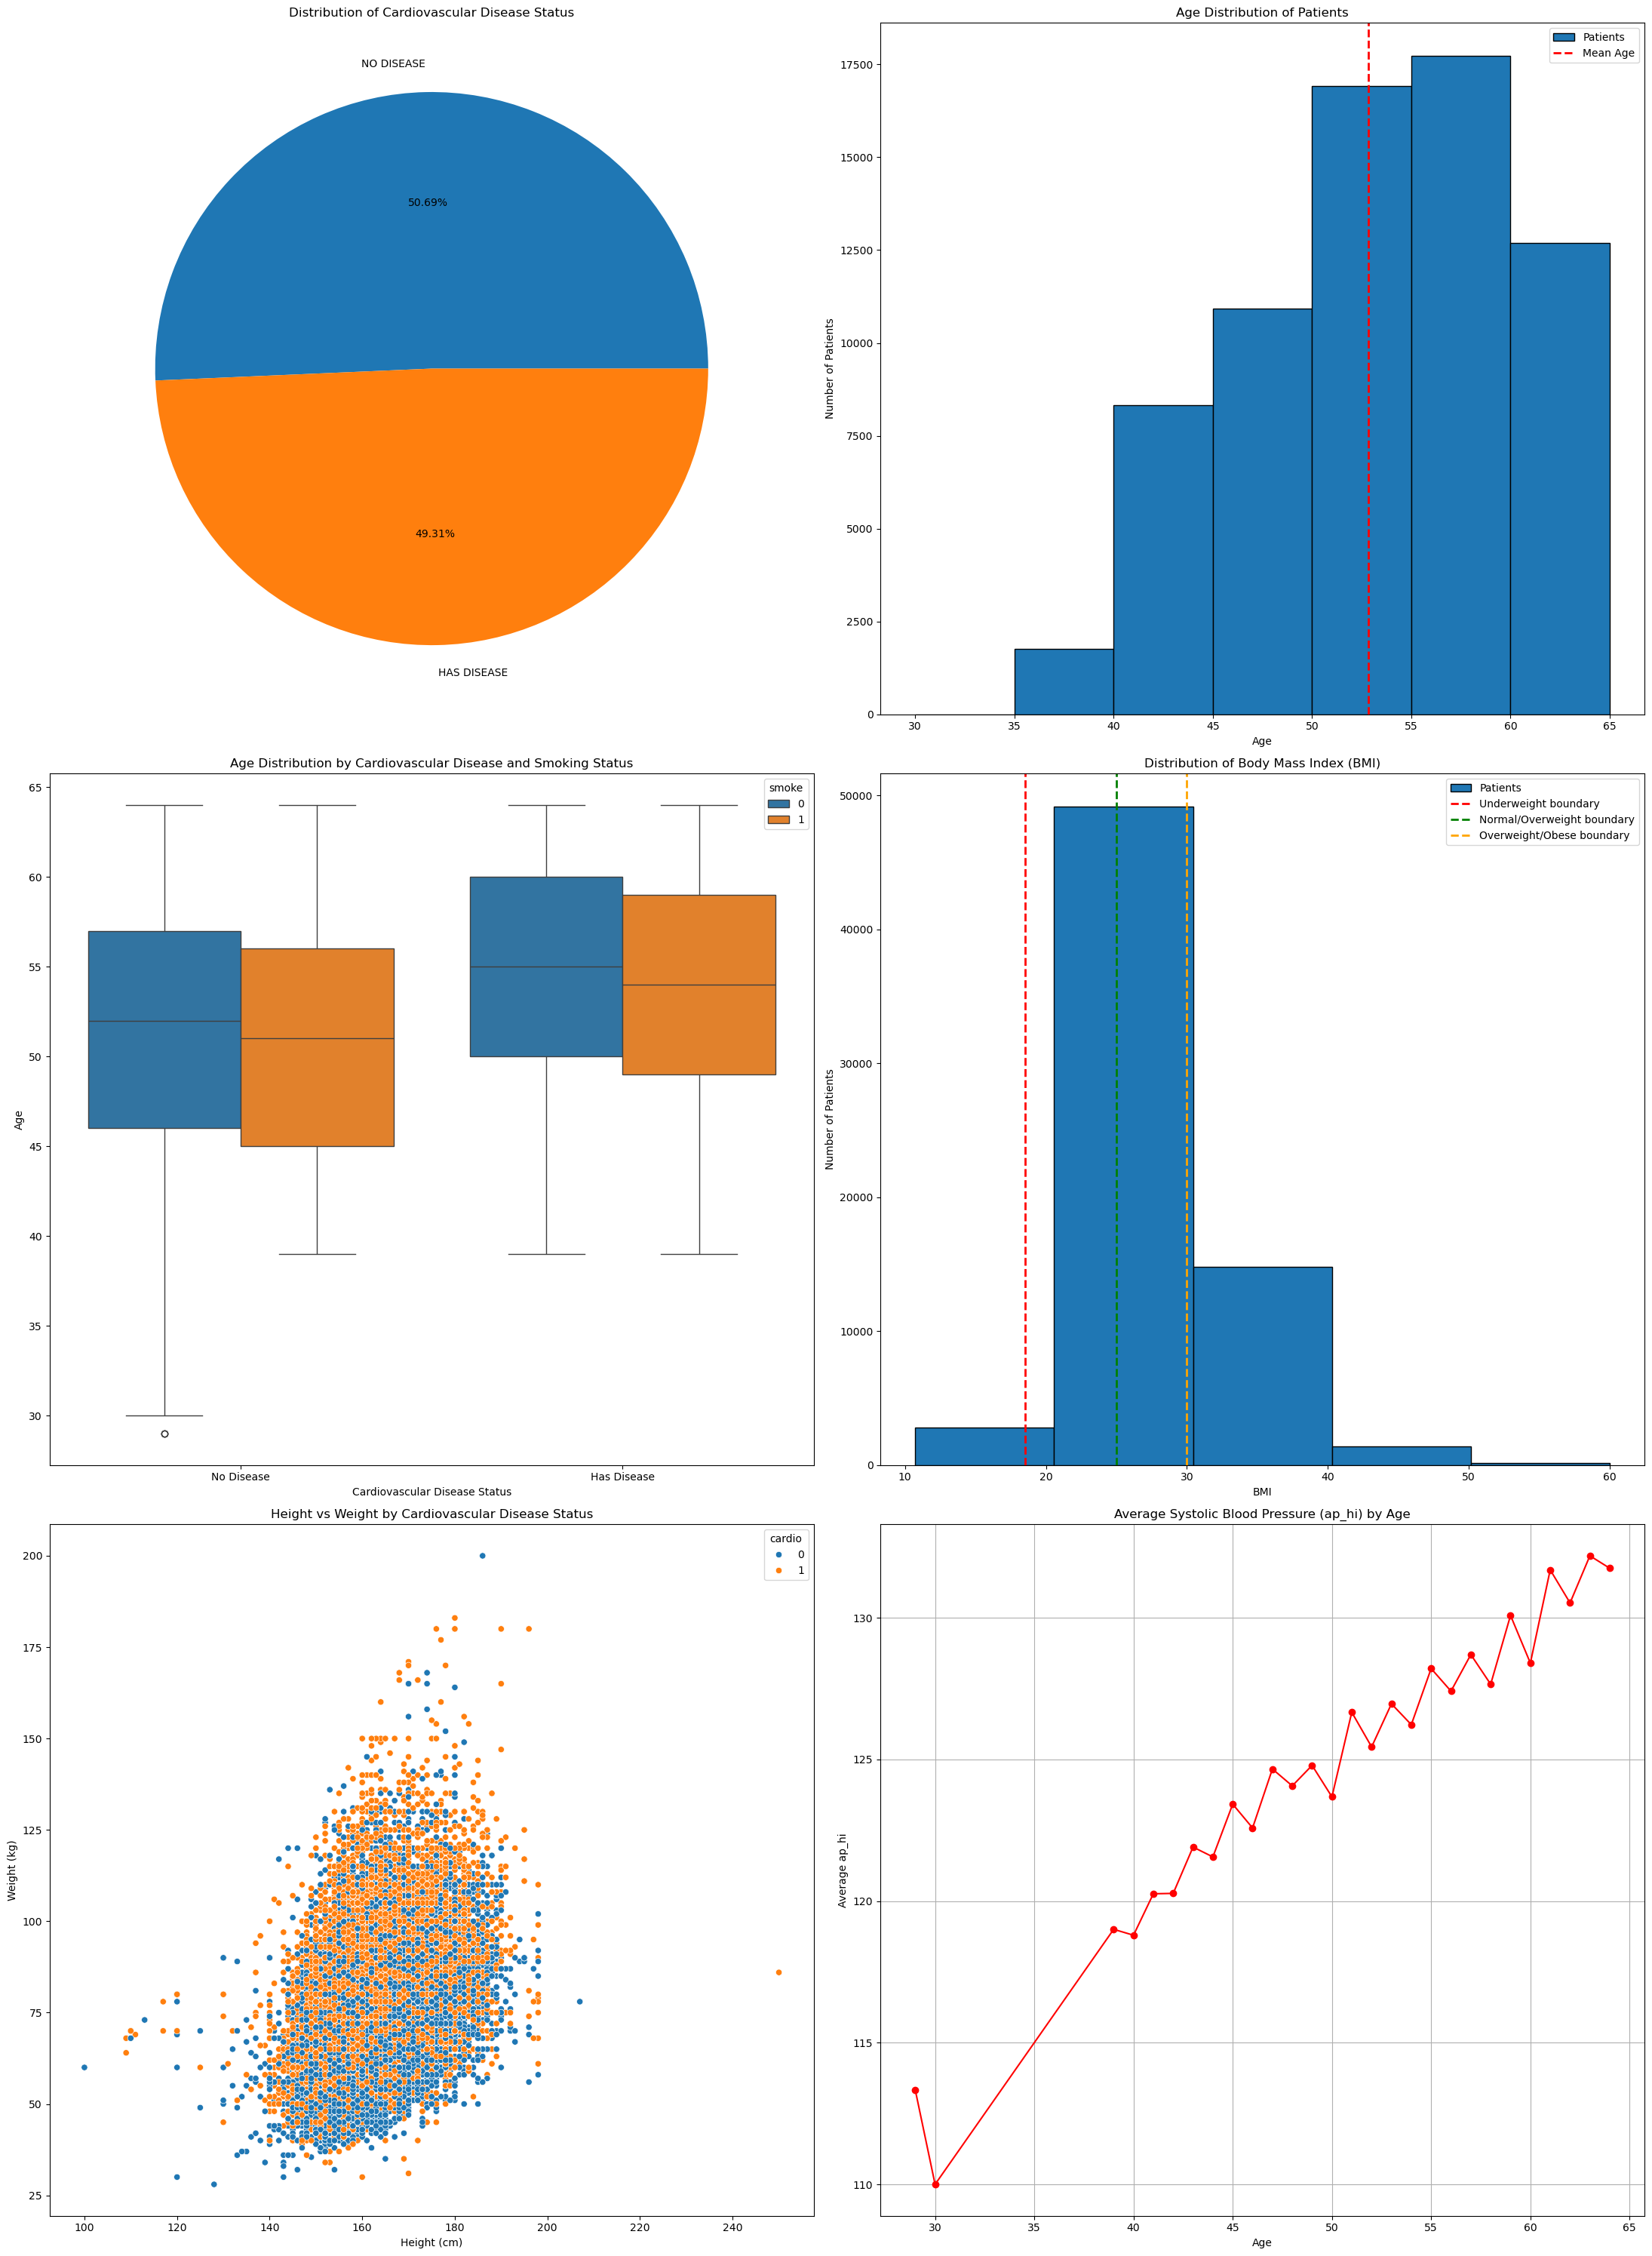

In [15]:
# Creating a 3x2 grid — 6 subplots in one professional dashboard
fig, ax = plt.subplots(3, 2, figsize=(22, 30))

# --- SUBPLOT 1 [0][0] --- Disease Distribution Pie Chart
cardio = df['cardio'].value_counts()
ax[0][0].pie(cardio.values, labels=['NO DISEASE', 'HAS DISEASE'], autopct='%1.2f%%')
ax[0][0].set_title('Distribution of Cardiovascular Disease Status')

# --- SUBPLOT 2 [0][1] --- Age Distribution Histogram
bins = [30, 35, 40, 45, 50, 55, 60, 65]
ax[0][1].hist(df['age'], bins=bins, edgecolor='black', label='Patients')
ax[0][1].set_title('Age Distribution of Patients')
ax[0][1].set_xlabel('Age')
ax[0][1].set_ylabel('Number of Patients')
ax[0][1].axvline(x=df['age'].mean(), color='red', linestyle='--', linewidth=2, label='Mean Age')
ax[0][1].legend()

# --- SUBPLOT 3 [1][0] --- Age vs Disease by Smoking — Box Plot
# ax= parameter directs Seaborn to draw on this specific subplot
sns.boxplot(x=df['cardio'], y=df['age'], hue=df['smoke'], ax=ax[1][0])
ax[1][0].set_title('Age Distribution by Cardiovascular Disease and Smoking Status')
ax[1][0].set_xlabel('Cardiovascular Disease Status')
ax[1][0].set_ylabel('Age')
ax[1][0].set_xticks([0, 1], ['No Disease', 'Has Disease'])

# --- SUBPLOT 4 [1][1] --- BMI Distribution with WHO Boundaries
# BMI filter reapplied to ensure clean data inside dashboard
df = df.loc[((df['bmi'] >= 10) & (df['bmi'] <= 60))]
ax[1][1].hist(df['bmi'], bins=5, edgecolor='black', label='Patients')
ax[1][1].axvline(x=18.5, color='red', linestyle='--', linewidth=2, label='Underweight boundary')
ax[1][1].axvline(x=25, color='green', linestyle='--', linewidth=2, label='Normal/Overweight boundary')
ax[1][1].axvline(x=30, color='orange', linestyle='--', linewidth=2, label='Overweight/Obese boundary')
ax[1][1].set_title('Distribution of Body Mass Index (BMI)')
ax[1][1].set_xlabel('BMI')
ax[1][1].set_ylabel('Number of Patients')
ax[1][1].legend()

# --- SUBPLOT 5 [2][0] --- Height vs Weight Scatter by Disease Status
sns.scatterplot(df, x='height', y='weight', hue='cardio', ax=ax[2][0])
ax[2][0].set_title('Height vs Weight by Cardiovascular Disease Status')
ax[2][0].set_xlabel('Height (cm)')
ax[2][0].set_ylabel('Weight (kg)')

# --- SUBPLOT 6 [2][1] --- Blood Pressure Trend by Age
# groupby age + mean gives average systolic BP per age group
data = df.groupby('age')['ap_hi'].mean()
ax[2][1].plot(data.index, data.values, marker='o', color='red')
ax[2][1].set_title('Average Systolic Blood Pressure (ap_hi) by Age')
ax[2][1].set_xlabel('Age')
ax[2][1].set_ylabel('Average ap_hi')
ax[2][1].grid()

fig.tight_layout()
plt.show()

---
## 🔍 Dataset Preview

In [16]:
# Displaying first 5 rows of the cleaned dataset
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177
